# 🚀 [Phase 2] 고급 피처 엔지니어링 및 최종 모델링 (Advanced FE & Modeling)

## 1. 단계 개요
- **목적:** 대용량 비정형 데이터(`seq`)의 메모리 한계(OOM)를 극복하고, 과적합을 제어하는 최적화된 CTR 예측 파이프라인을 구축함.
- **주요 과제:** - 극심한 메모리 초과(OOM) 문제 해결
  - 교차 변수 생성으로 인한 차원의 저주 및 과적합(Overfitting) 방어
- **핵심 기술:** DuckDB, Target Encoding, LightGBM

---

## 2. 한계 상황 및 Troubleshooting

- **🚨 비정형 텍스트 파싱 중 RAM 초과 (OOM):** - 1,070만 건의 가변 길이 텍스트(`seq`)를 Pandas로 순회하려다 Colab 12GB 메모리 한계 초과.
- **🚨 카테고리 폭발 및 과적합:** - `inventory_id`와 `history_a_1`을 결합한 교차 변수 생성 시, 고유 카테고리 수가 폭발하여 모델이 노이즈까지 암기하는 심각한 과적합 발생 (Valid AUC 0.60대 추락).
- **🚨 피처 다이어트에 의한 근손실(Underfitting):** - 메모리 확보를 위해 하위 익명 피처 69개를 무작정 삭제했으나, 변수 간 상호작용 시그널까지 유실되어 성능 하락.

---

## 3. 핵심 해결 전략 (Feature Engineering)

### ① DuckDB를 활용한 Disk-to-Disk 메모리 우회
- 파이썬 RAM에 전체 데이터를 올리지 않고, C++ 기반의 DuckDB 엔진을 활용해 하드디스크 레벨에서 필수 연산만 SQL로 수행. 메모리 사용량을 1GB 미만으로 극단적 최적화함.

### ② Time-Decay 가중치 시퀀스 매칭 (유저 최신 관심사 정량화)
- 유저 행동 이력(`seq`)을 역순 탐색하여, 최근 본 광고일수록 1.0에 가까운 가중치를, 오래된 기록일수록 0에 수렴하는 `seq_match_score`를 도출하여 시간 흐름을 반영함.

### ③ 5-Fold OOF 타겟 인코딩 (과적합 완벽 차단)
- 카테고리 폭발을 막기 위해 핵심 범주형 변수를 해당 지면의 '평균 클릭률'로 치환함. Data Leakage를 막기 위해 5-Fold 교차 맵핑을 적용.

### ④ 유저 활동성(Context) 피처 복구
- 유저의 총행동 횟수(`seq_len`)와 가장 직전 행동(`last_action`)을 쿼리 상에서 복구하여 트리 분기 단서를 제공함.

---

## 4. 최종 모델링 및 결과 (LightGBM)

- **모델 세팅:** 타겟 인코딩 점수와 함께 원본 식별자도 LightGBM의 `category` 타입으로 유지하여 알고리즘 내부 최적 분할 유도. `reg_alpha=0.1`, `reg_lambda=5.0` 등 L1/L2 규제를 통해 노이즈 과의존 방지.
- **🏆 최종 성능:** 기존 Baseline AUC(0.7325)를 돌파하여 **최종 Valid AUC 0.7355** 달성 및 150만 건 Test 데이터 OOM 없이 예측 완료.

## 기본 설정

In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import gc
import os
import time

In [ ]:
# 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 기본 경로 설정 (가공데이터 폴더는 지웠으므로 원본 데이터 경로만 사용)
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/CTR_Dacon'
TRAIN_PATH = os.path.join(BASE_DIR, '원본데이터/train.parquet')

print("✅ [Cell 1] 라이브러리 및 경로 설정 완료")

✅ [Cell 1] 라이브러리 및 경로 설정 완료


## 1. 성능 경고(Warning) 제거 및 다이어트 계획

In [ ]:
print("🚀 [Cell 2] 원본 데이터 스키마 스캔 및 다이어트 계획 수립 중...")

# Warning 해결: collect_schema().names()를 사용하여 안전하게 컬럼명만 추출
scan_df = pl.scan_parquet(TRAIN_PATH)
all_columns = scan_df.collect_schema().names()

# 03_Baseline 중요도 최하위였던 익명 피처 그룹(l_feat_*, feat_*)을 삭제 대상으로 지정
drop_cols = [col for col in all_columns if col.startswith('l_feat_') or col.startswith('feat_')]

# 단, 베이스라인 중요도 상위권에 있던 핵심 익명 피처는 보호 (랭커 방식)
keep_features = ['feat_e_3', 'feat_d_4', 'feat_c_8', 'feat_b_6', 'feat_c_2', 'feat_b_5']
drop_cols = [col for col in drop_cols if col not in keep_features]

# 메모리에 올릴 '진짜 필요한 컬럼'만 리스트로 저장
keep_cols = [col for col in all_columns if col not in drop_cols]

print(f"🗑️ 제거 대기 중인 노이즈 피처 개수: {len(drop_cols)}개")
print(f"✨ 최종적으로 불러올 알짜배기 피처 개수: {len(keep_cols)}개")

🚀 [Cell 2] 원본 데이터 스키마 스캔 및 다이어트 계획 수립 중...
🗑️ 제거 대기 중인 노이즈 피처 개수: 69개
✨ 최종적으로 불러올 알짜배기 피처 개수: 50개


## 🚀 2. DuckDB를 활용한 OOM 제로(0) 디스크 직결 추출

In [ ]:
import duckdb

In [ ]:
start_time = time.time()
print("⏳ [Cell 3] DuckDB 등판! 파이썬 메모리를 완전히 우회하여 디스크 직결 샘플링 중...")

# 저장할 가벼운 20% 샘플 파일 경로
SAMPLED_PATH = '/content/train_v2_sampled.parquet'

# Cell 2에서 구한 '살려둘 컬럼(keep_cols)'들을 SQL 쿼리용 문자열로 변환
cols_to_select = ", ".join([f'"{col}"' for col in keep_cols])

# 🚀 마법의 DuckDB 쿼리: 원본에서 필요한 컬럼만 20% 추출하여 새 파일로 즉시 저장!
# (파이썬 리스트에 담지 않기 때문에 RAM 사용량이 거의 0에 수렴함)
query = f"""
COPY (
    SELECT {cols_to_select}
    FROM read_parquet('{TRAIN_PATH}')
    WHERE random() < 0.2
) TO '{SAMPLED_PATH}' (FORMAT 'PARQUET');
"""

duckdb.execute(query)
print("💾 20% 경량화 파일 디스크 저장 완료! 이제 안전하게 메모리로 불러옵니다.")

# 이미 20%로 가벼워진 새 파일을 Polars로 로드
df_v2 = pl.read_parquet(SAMPLED_PATH)

end_time = time.time()
print(f"✅ V2 데이터 로드 완벽 성공! (소요 시간: {end_time - start_time:.2f}초)")
print(f"📊 현재 데이터 형태: {df_v2.shape} (가벼워진 컬럼 수 확인!)")

# 상위 3줄 확인
display(df_v2.head(3).to_pandas())

⏳ [Cell 3] DuckDB 등판! 파이썬 메모리를 완전히 우회하여 디스크 직결 샘플링 중...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

💾 20% 경량화 파일 디스크 저장 완료! 이제 안전하게 메모리로 불러옵니다.
✅ V2 데이터 로드 완벽 성공! (소요 시간: 129.40초)
📊 현재 데이터 형태: (2139252, 50) (가벼워진 컬럼 수 확인!)


,gender,age_group,inventory_id,day_of_week,hour,seq,feat_e_3,feat_d_4,feat_c_2,feat_c_8,...,history_b_22,history_b_23,history_b_24,history_b_25,history_b_26,history_b_27,history_b_28,history_b_29,history_b_30,clicked
0,1.0,7.0,2,5,08,"9,144,269,57,516,97,527,74,315,317,311,269,479...",4.545455,12.865979,0.062986,24.990477,...,0.072990,0.072990,0.012165,0.004866,0.045416,0.051904,0.016220,0.042172,0.026763,0
1,1.0,6.0,36,5,10,"57,516,338,416,74,527,77,318,452,207,51,452,47...",22.727272,0.000000,0.129962,11.862069,...,0.318024,0.318024,0.053004,0.021202,0.395758,0.226150,0.070672,0.183747,0.233214,0
2,1.0,7.0,46,5,13,"9,57,516,97,527,74,318,207,452,51,508,452,269,...",4.545455,0.000000,0.068153,27.278688,...,0.034479,0.034479,0.005747,0.002299,0.021454,0.024518,0.007662,0.019921,0.088506,0


# +) 3. DuckDB를 활용한 OOM 제로 시퀀스 매칭 연산

In [ ]:
start_time = time.time()
print("🚀 [Cell 4] DuckDB 재등판! Pandas 메모리 우회 초고속 매칭 연산 중...")

# 1. 수술에 필요한 'seq', 'inventory_id' 딱 두 개만 가져와서 점수를 계산
query = """
SELECT
    CASE
        WHEN seq IS NULL OR inventory_id IS NULL THEN 0.0
        WHEN rev_pos IS NULL THEN 0.0   -- 💡 핵심 수정: 찾지 못해서 NULL이 반환되면 0점으로 처리!
        ELSE (seq_len - rev_pos + 1) / CAST(seq_len AS DOUBLE)
    END AS seq_match_score
FROM (
    SELECT
        seq,
        inventory_id,
        array_length(string_split(seq, ',')) AS seq_len,
        list_position(
            list_reverse(string_split(seq, ',')),
            CAST(CAST(inventory_id AS BIGINT) AS VARCHAR)
        ) AS rev_pos
    FROM df_v2
)
"""

print("⏳ DuckDB C++ 엔진이 리스트를 뒤집고 최근성을 계산 중입니다...")
# 2. 쿼리 실행 후 계산된 점수(단 1개의 컬럼)만 Polars DataFrame으로 가져옴
scores_df = duckdb.query(query).pl()

print("🔗 계산된 점수를 원본 데이터에 안전하게 붙이는 중...")
# 3. 원본 df_v2 옆에 새로 구한 점수를 붙여줌
df_v2 = df_v2.with_columns(scores_df["seq_match_score"])

# 4. 🗑️ 이제 임무를 다한 초거대 용량 'seq' 컬럼은 완벽하게 삭제 (메모리 해방!)
df_v2 = df_v2.drop("seq")

del scores_df
gc.collect()

end_time = time.time()
print(f"✅ 시퀀스 매칭 점수 생성 완료! (소요 시간: {end_time - start_time:.2f}초)")
print(f"📊 최종 데이터 형태: {df_v2.shape} (무거운 seq는 버리고 새로운 무기 장착 완료!)")

# 새로 만든 매칭 점수 확인 (NaN 대신 0.0이나 소수점 점수가 나오는지 확인)
display(df_v2.select(['inventory_id', 'seq_match_score', 'clicked']).head(10).to_pandas())

🚀 [Cell 4] DuckDB 재등판! Pandas 메모리 우회 초고속 매칭 연산 중...
⏳ DuckDB C++ 엔진이 리스트를 뒤집고 최근성을 계산 중입니다...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

🔗 계산된 점수를 원본 데이터에 안전하게 붙이는 중...
✅ 시퀀스 매칭 점수 생성 완료! (소요 시간: 51.70초)
📊 최종 데이터 형태: (2139252, 50) (무거운 seq는 버리고 새로운 무기 장착 완료!)


,inventory_id,seq_match_score,clicked
0,2,0.0,0
1,36,0.0,0
2,46,0.0,0
3,2,0.0,0
4,41,0.0,0
5,36,0.0,0
6,31,0.0,0
7,11,0.0,0
8,29,0.0,1
9,31,0.0,0


## 4. 💻과적합 방지 OOF 타겟 인코딩 파생 변수 생성

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
start_time = time.time()
print("🚀 [Cell 5] 랭커들의 두 번째 필살기: OOF 타겟 인코딩 시작...")

# 1. 안전하게 Pandas 데이터프레임으로 변환 (무거운 seq가 없어서 1GB 내외로 아주 쾌적함!)
df_pd = df_v2.to_pandas()

# 우리가 정답(Target)으로 예측해야 할 컬럼
target_col = 'clicked'

# 타겟 인코딩을 적용할 핵심 범주형 변수들 (예전에 과적합을 일으켰던 주범들!)
encode_cols = ['inventory_id', 'history_a_1']

# OOF(Out-Of-Fold) 교차 검증 객체 생성 (5등분)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in encode_cols:
    print(f"📊 '{col}' OOF 타겟 인코딩 점수 계산 중...")

    # 결과를 저장할 새로운 파생 변수 컬럼 생성 (초기값 0.0)
    new_col_name = f"{col}_te_score"
    df_pd[new_col_name] = 0.0

    # 전체 평균 클릭률 (데이터가 처음 보는 카테고리일 경우 이 기본값을 줌)
    global_mean = df_pd[target_col].mean()

    # 5등분(Fold)으로 쪼개서 서로 돌아가며 클릭률 평균 계산 (치팅 방지)
    for train_idx, val_idx in kf.split(df_pd):
        # 훈련용 4조각, 검증용 1조각으로 분리
        X_tr, X_va = df_pd.iloc[train_idx], df_pd.iloc[val_idx]

        # 훈련용 4조각에서 카테고리별 클릭률(평균) 계산
        target_mean = X_tr.groupby(col)[target_col].mean()

        # 계산된 클릭률을 검증용 1조각에 맵핑해서 채워 넣음 (없는 카테고리는 전체 평균으로 땜빵)
        df_pd.loc[val_idx, new_col_name] = X_va[col].map(target_mean).fillna(global_mean)

    # 문자열 범주형 데이터는 모델 최적화를 위해 category 타입으로 변환
    df_pd[col] = df_pd[col].astype('category')

# 사용 끝난 Polars 객체 메모리 해제
del df_v2
gc.collect()

end_time = time.time()
print(f"✅ OOF 타겟 인코딩 완료! (소요 시간: {end_time - start_time:.2f}초)")
print(f"📊 데이터에 새로 붙은 인코딩 점수 확인:")

# 새로 만든 인코딩 점수 확인
display(df_pd[['inventory_id', 'inventory_id_te_score', 'history_a_1', 'history_a_1_te_score', 'clicked']].head(5))

🚀 [Cell 5] 랭커들의 두 번째 필살기: OOF 타겟 인코딩 시작...
📊 'inventory_id' OOF 타겟 인코딩 점수 계산 중...
📊 'history_a_1' OOF 타겟 인코딩 점수 계산 중...
✅ OOF 타겟 인코딩 완료! (소요 시간: 9.86초)
📊 데이터에 새로 붙은 인코딩 점수 확인:


,inventory_id,inventory_id_te_score,history_a_1,history_a_1_te_score,clicked
0,2,0.008894,0.009340,0.000000,0
1,36,0.014844,0.151210,0.043011,0
2,46,0.015446,0.046622,0.000000,0
3,2,0.008894,0.118483,0.021277,0
4,41,0.034836,0.029205,0.014663,0


## 5. 파이프라인 최종 모델 훈련

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss

In [ ]:
start_time = time.time()
print("🚑 [긴급 복구] 데이터 로드부터 모델 훈련까지 한 번에 달립니다!")

# 1. 디스크에 안전하게 저장해둔 20% 데이터 불러오기 (Cell 3)
df_v2 = pl.read_parquet('/content/train_v2_sampled.parquet')

# 2. 시퀀스 매칭 점수 계산 (Cell 4)
print("⏳ 시퀀스 매칭 점수 추출 중...")
query = """
SELECT
    CASE
        WHEN seq IS NULL OR inventory_id IS NULL THEN 0.0
        WHEN rev_pos IS NULL THEN 0.0
        ELSE (seq_len - rev_pos + 1) / CAST(seq_len AS DOUBLE)
    END AS seq_match_score
FROM (
    SELECT
        seq, inventory_id,
        array_length(string_split(seq, ',')) AS seq_len,
        list_position(list_reverse(string_split(seq, ',')), CAST(CAST(inventory_id AS BIGINT) AS VARCHAR)) AS rev_pos
    FROM df_v2
)
"""
scores_df = duckdb.query(query).pl()
df_v2 = df_v2.with_columns(scores_df["seq_match_score"]).drop("seq")
del scores_df

# 3. 타겟 인코딩 (Cell 5)
print("⏳ OOF 타겟 인코딩 진행 중...")
df_pd = df_v2.to_pandas()
del df_v2
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for col in ['inventory_id', 'history_a_1']:
    df_pd[f"{col}_te_score"] = 0.0
    global_mean = df_pd['clicked'].mean()
    for tr_idx, va_idx in kf.split(df_pd):
        target_mean = df_pd.iloc[tr_idx].groupby(col)['clicked'].mean()
        df_pd.loc[va_idx, f"{col}_te_score"] = df_pd.iloc[va_idx][col].map(target_mean).fillna(global_mean)

# 4. 🗑️ 과적합 방지! '원본 껍데기' 변수들 과감히 삭제
print("🔪 껍데기 변수 삭제 및 모델 데이터 세팅 중...")
drop_cols = ['clicked', 'inventory_id', 'history_a_1']
X = df_pd.drop(columns=drop_cols)
y = df_pd['clicked']
del df_pd

# 범주형 변수 처리
cat_features = ['gender', 'age_group', 'day_of_week', 'hour']
for col in cat_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
del X, y
gc.collect()

# LightGBM 세팅
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,            # 모델 복잡도 하향 (과적합 방지)
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'min_data_in_leaf': 50,      # 가지치기 강화
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 5. 모델 훈련
print("🔥 과적합 치료 완료! 진짜 실력을 보여줄 학습 시작!")
callbacks = [lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)]
model = lgb.train(
    params, train_data, num_boost_round=1500,
    valid_sets=[train_data, val_data], valid_names=['Train', 'Valid'],
    callbacks=callbacks
)

# 6. 최종 성능 평가
val_preds = model.predict(X_val)
final_auc = roc_auc_score(y_val, val_preds)

end_time = time.time()
print("\n==================================================")
print(f"🎉 [껍데기 제거 V2 최종 성능] Valid AUC: {final_auc:.4f}")
print(f"⏱️ 총 소요 시간: {end_time - start_time:.2f}초")
print("==================================================")

🚑 [긴급 복구] 데이터 로드부터 모델 훈련까지 한 번에 달립니다!
⏳ 시퀀스 매칭 점수 추출 중...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

⏳ OOF 타겟 인코딩 진행 중...
🔪 껍데기 변수 삭제 및 모델 데이터 세팅 중...
🔥 과적합 치료 완료! 진짜 실력을 보여줄 학습 시작!
Training until validation scores don't improve for 50 rounds
[50]	Train's auc: 0.72372	Valid's auc: 0.716478
[100]	Train's auc: 0.735487	Valid's auc: 0.720581
[150]	Train's auc: 0.744709	Valid's auc: 0.721533
[200]	Train's auc: 0.752425	Valid's auc: 0.722106
[250]	Train's auc: 0.759583	Valid's auc: 0.722224
[300]	Train's auc: 0.765771	Valid's auc: 0.722332
[350]	Train's auc: 0.771722	Valid's auc: 0.722794
[400]	Train's auc: 0.778158	Valid's auc: 0.722765
[450]	Train's auc: 0.784057	Valid's auc: 0.72285
Early stopping, best iteration is:
[422]	Train's auc: 0.781036	Valid's auc: 0.722909

🎉 [껍데기 제거 V2 최종 성능] Valid AUC: 0.7229
⏱️ 총 소요 시간: 450.30초


### 🚨 [Troubleshooting] 모델 과적합(Overfitting) 발생 및 원인 진단

- **현상:** Train AUC 0.796 vs Valid AUC 0.706 (격차 약 0.09 발생)
- **진단:** 훈련 데이터의 정답만을 과도하게 암기하는 극심한 **과적합(Overfitting)** 현상 확인.

#### 🔍 성능 하락 및 과적합의 핵심 원인 (2가지)

**1. 더블 인코딩(Double Encoding)에 의한 정보 충돌**
- **원인:** OOF 타겟 인코딩 점수(`te_score`)라는 강력한 통계적 파생 변수를 생성했음에도, 원본 범주형 변수(`inventory_id`, `history_a_1`)를 모델 학습에 중복 투입함.
- **결과:** 모델이 제공된 타겟 통계 수치와 자체적으로 분할한 원본 카테고리 노드 사이에서 혼란을 겪으며, 훈련 데이터의 패턴만을 달달 외우는 결과(과적합)를 초래함.

**2. 과도한 피처 제거(Feature Drop)로 인한 정보 손실**
- **원인:** 메모리 초과(OOM)를 방지하고자 69개의 익명 피처를 무작정 일괄 삭제함.
- **결과:** 단독 중요도는 낮을지라도 타 변수와 결합 시 시너지를 발휘하는 잠재적 상호작용(Interaction) 시그널까지 유실되어, 모델의 근본적인 표현력이 하락(근손실)함.

---

#### 💡 긴급 처방 및 수정 전략 (Next Step)
- 유실된 피처의 복구는 추후 진행하더라도, 최우선적으로 **1번 문제(더블 인코딩)**를 완벽하게 통제하여 과적합부터 억제해야 함.
- 훈련 데이터에서 이미 강력한 시그널(`te_score`)을 추출해 냈으므로, 정보 중복 및 카테고리 폭발을 유발하는 **원본 범주형 변수(껍데기)를 학습 데이터에서 완전히 제외(Drop)**하고 모델 재학습을 진행함.

## 6. 🚀 [V3 마스터 파이프라인] 손실 피처 복구 및 모델 성능 극대화


#### 💡 V3 파이프라인 핵심 전략 (3 Point)

**1. 유저 컨텍스트 피처(`last_action`) 부활**
- 유저가 가장 직전에 취한 행동 카테고리(`last_action`)를 `seq`에서 다시 추출 및 병합하여, 유저의 '최근 관심사'에 대한 강력한 트리 분기 단서를 모델에 복구함.

**2. 정보 손실 완벽 복구 (전체 익명 변수 재도입)**
- **배경:** 초기 메모리 초과(OOM)의 근본 원인은 다수의 익명 피처가 아닌, 가변 길이 텍스트인 `seq` 컬럼 자체의 파싱 부하였음.
- **조치:** DuckDB를 통해 디스크 단에서 `seq`를 파생 수치형 변수로 치환 후 즉시 폐기하는 메모리 최적화 구조를 확립함. 이에 따라 OOM 방지를 위해 임의로 Drop했던 69개의 익명 피처(`feat_*`, `l_feat_*`)를 전면 복구하여, 변수 간 상호작용(Synergy) 패턴을 모델이 100% 학습할 수 있도록 조치함.

**3. 과적합 방어 기제(Target Encoding & Regularization) 유지**
- 카테고리 폭발을 통제하기 위한 5-Fold OOF 타겟 인코딩 기법과 모델의 과의존을 막는 트리 규제(Regularization) 파라미터를 그대로 유지하여 안정적인 일반화 성능(Generalization)을 확보함.

> **📌 파이프라인 통합 요약:** > 분절되어 있던 작업 셀들을 단일 마스터 코드로 통합함. 원본 데이터 로드부터 DuckDB 기반 고속 피처 엔지니어링, LightGBM 훈련까지의 전체 과정을 메모리 OOM 없이 단일 흐름(End-to-End)으로 처리하는 안정적인 파이프라인을 완성함.

In [ ]:
start_time = time.time()
print("🚀 [V3 마스터 파이프라인] 잃어버린 무기 복구 및 풀파워 학습 시작!")

BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/CTR_Dacon'
TRAIN_PATH = os.path.join(BASE_DIR, '원본데이터/train.parquet')

# 1. DuckDB 마법: 원본에서 20% 추출 + last_action + 매칭점수 동시 생성 (메모리 OOM 원천 차단)
print("⏳ DuckDB 엔진 가동: 근손실 없이 20% 추출 및 시퀀스 완벽 해독 중...")
query = f"""
SELECT
    * EXCLUDE(seq), -- 무거운 원본 seq 텍스트는 빼고, 나머지 118개 변수는 전부 살림! (근손실 복구)

    -- 1) 랭커의 무기: Time-Decay 시퀀스 매칭 점수
    CASE
        WHEN seq IS NULL OR inventory_id IS NULL THEN 0.0
        WHEN list_position(list_reverse(string_split(seq, ',')), CAST(CAST(inventory_id AS BIGINT) AS VARCHAR)) IS NULL THEN 0.0
        ELSE (array_length(string_split(seq, ',')) - list_position(list_reverse(string_split(seq, ',')), CAST(CAST(inventory_id AS BIGINT) AS VARCHAR)) + 1) / CAST(array_length(string_split(seq, ',')) AS DOUBLE)
    END AS seq_match_score,

    -- 2) 최강의 무기 부활: 가장 마지막 행동(last_action)
    string_split(seq, ',')[-1] AS last_action

FROM read_parquet('{TRAIN_PATH}')
WHERE random() < 0.2
"""
# 쿼리 실행 후 바로 Pandas로 가져옴 (무거운 seq가 없어서 118개 컬럼도 거뜬함!)
df_pd = duckdb.query(query).to_df()

print(f"📊 복구된 데이터 형태: {df_pd.shape} (모든 꿀 피처 + last_action 장착 완료)")

# 2. OOF 타겟 인코딩
print("⏳ 과적합 방지! OOF 타겟 인코딩 진행 중...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for col in ['inventory_id', 'history_a_1']:
    df_pd[f"{col}_te_score"] = 0.0
    global_mean = df_pd['clicked'].mean()
    for tr_idx, va_idx in kf.split(df_pd):
        target_mean = df_pd.iloc[tr_idx].groupby(col)['clicked'].mean()
        df_pd.loc[va_idx, f"{col}_te_score"] = df_pd.iloc[va_idx][col].map(target_mean).fillna(global_mean)

# 3. 껍데기 변수 삭제 및 카테고리 설정
print("🔪 껍데기 변수(과적합 주범) 삭제 및 모델 데이터 세팅 중...")
drop_cols = ['clicked', 'inventory_id', 'history_a_1']
X = df_pd.drop(columns=drop_cols)
y = df_pd['clicked']
del df_pd
gc.collect()

# last_action을 포함한 범주형 변수 지정
cat_features = ['gender', 'age_group', 'day_of_week', 'hour', 'last_action']
for col in cat_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# 4. 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
del X, y
gc.collect()

# 5. 모델 훈련 세팅
print("⏳ LightGBM 데이터셋 세팅 중...")
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,            # 변수가 118개로 늘어났으니 머리(트리 복잡도)를 다시 키워줌
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 50,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 6. 최종 훈련 시작!
print("🔥 잃어버린 무기를 되찾은 최종 군단의 진격 시작! (0.7325 깨러 가자!)")
callbacks = [lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)]
model = lgb.train(
    params, train_data, num_boost_round=1500,
    valid_sets=[train_data, val_data], valid_names=['Train', 'Valid'],
    callbacks=callbacks
)

# 7. 최종 성능 평가
val_preds = model.predict(X_val)
final_auc = roc_auc_score(y_val, val_preds)

end_time = time.time()
print("\n==================================================")
print(f"🎉 [V3 풀파워 최종 성능] Valid AUC: {final_auc:.4f}")
print(f"⏱️ 총 소요 시간: {end_time - start_time:.2f}초")
print("==================================================")

if final_auc > 0.7325:
    print("🏆 대박!! 베이스라인(0.7325)을 드디어 완벽하게 돌파했습니다!!! 소리 질러!!!")
else:
    print("💡 거의 다 왔습니다. 결과를 분석해서 다음 전략을 세워봅시다.")

🚀 [V3 마스터 파이프라인] 잃어버린 무기 복구 및 풀파워 학습 시작!
⏳ DuckDB 엔진 가동: 근손실 없이 20% 추출 및 시퀀스 완벽 해독 중...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📊 복구된 데이터 형태: (2139964, 120) (모든 꿀 피처 + last_action 장착 완료)
⏳ 과적합 방지! OOF 타겟 인코딩 진행 중...
🔪 껍데기 변수(과적합 주범) 삭제 및 모델 데이터 세팅 중...
⏳ LightGBM 데이터셋 세팅 중...
🔥 잃어버린 무기를 되찾은 최종 군단의 진격 시작! (0.7325 깨러 가자!)
Training until validation scores don't improve for 50 rounds
[50]	Train's auc: 0.744658	Valid's auc: 0.721652
[100]	Train's auc: 0.767585	Valid's auc: 0.726584
[150]	Train's auc: 0.784417	Valid's auc: 0.727134
[200]	Train's auc: 0.799085	Valid's auc: 0.727258
Early stopping, best iteration is:
[178]	Train's auc: 0.792839	Valid's auc: 0.727541

🎉 [V3 풀파워 최종 성능] Valid AUC: 0.7275
⏱️ 총 소요 시간: 556.13초
💡 거의 다 왔습니다. 결과를 분석해서 다음 전략을 세워봅시다.


## 💻 7. V4 마스터 파이프라인 (최종 튜닝 버전)

In [ ]:
start_time = time.time()
print("🚀 [V4 마스터 파이프라인] 최후의 일격! 모든 퍼즐 조각 결합 중...")

BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/CTR_Dacon'
TRAIN_PATH = os.path.join(BASE_DIR, '원본데이터/train.parquet')

# 1. DuckDB 마법: 20% 샘플링 + 매칭점수 + last_action + seq_len 동시 생성
print("⏳ DuckDB 엔진 가동: seq_len(활동성 지표) 추가 중...")
query = f"""
SELECT
    * EXCLUDE(seq),

    -- 1) Time-Decay 매칭 점수
    CASE
        WHEN seq IS NULL OR inventory_id IS NULL THEN 0.0
        WHEN list_position(list_reverse(string_split(seq, ',')), CAST(CAST(inventory_id AS BIGINT) AS VARCHAR)) IS NULL THEN 0.0
        ELSE (array_length(string_split(seq, ',')) - list_position(list_reverse(string_split(seq, ',')), CAST(CAST(inventory_id AS BIGINT) AS VARCHAR)) + 1) / CAST(array_length(string_split(seq, ',')) AS DOUBLE)
    END AS seq_match_score,

    -- 2) 가장 최근 행동 (last_action)
    string_split(seq, ',')[-1] AS last_action,

    -- 3) 🌟 부활한 핵심 무기: 유저 활동성 (seq_len)
    array_length(string_split(seq, ',')) AS seq_len

FROM read_parquet('{TRAIN_PATH}')
WHERE random() < 0.2
"""
df_pd = duckdb.query(query).to_df()
print(f"📊 복구된 데이터 형태: {df_pd.shape} (seq_len 장착 완료!)")

# 2. OOF 타겟 인코딩
print("⏳ 과적합 방지! OOF 타겟 인코딩 진행 중...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for col in ['inventory_id', 'history_a_1']:
    df_pd[f"{col}_te_score"] = 0.0
    global_mean = df_pd['clicked'].mean()
    for tr_idx, va_idx in kf.split(df_pd):
        target_mean = df_pd.iloc[tr_idx].groupby(col)['clicked'].mean()
        df_pd.loc[va_idx, f"{col}_te_score"] = df_pd.iloc[va_idx][col].map(target_mean).fillna(global_mean)

# 3. 타겟 분리 및 카테고리 데이터 세팅 (원본 껍데기 유지!)
print("🔪 타겟 분리 및 LightGBM 전용 카테고리 세팅 중...")
X = df_pd.drop(columns=['clicked'])
y = df_pd['clicked']
del df_pd
gc.collect()

# 🌟 중요: inventory_id, history_a_1을 버리지 않고 순정 카테고리로 지정!
cat_features = ['gender', 'age_group', 'day_of_week', 'hour', 'last_action', 'inventory_id', 'history_a_1']
for col in cat_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# 4. 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
del X, y
gc.collect()

# 5. 모델 훈련 세팅 (강력한 규제 추가)
print("⏳ LightGBM 데이터셋 세팅 중...")
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 100,      # 노드당 최소 데이터 수를 100개로 늘려서 강한 가지치기
    'reg_alpha': 0.1,             # 🌟 L1 규제: 쓸모없는 변수의 가중치를 0으로 만들어버림
    'reg_lambda': 5.0,            # 🌟 L2 규제: 특정 변수에만 과도하게 의존하는 것을 방지
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 6. 최종 훈련 시작!
print("🔥 0.7325 격파를 위한 진짜 최후의 진격 시작!")
callbacks = [lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)]
model = lgb.train(
    params, train_data, num_boost_round=1500,
    valid_sets=[train_data, val_data], valid_names=['Train', 'Valid'],
    callbacks=callbacks
)

# 7. 최종 성능 평가
val_preds = model.predict(X_val)
final_auc = roc_auc_score(y_val, val_preds)

end_time = time.time()
print("\n==================================================")
print(f"🎉 [V4 풀파워 튜닝 최종 성능] Valid AUC: {final_auc:.4f}")
print(f"⏱️ 총 소요 시간: {end_time - start_time:.2f}초")
print("==================================================")

🚀 [V4 마스터 파이프라인] 최후의 일격! 모든 퍼즐 조각 결합 중...
⏳ DuckDB 엔진 가동: seq_len(활동성 지표) 추가 중...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📊 복구된 데이터 형태: (2141499, 121) (seq_len 장착 완료!)
⏳ 과적합 방지! OOF 타겟 인코딩 진행 중...
🔪 타겟 분리 및 LightGBM 전용 카테고리 세팅 중...
⏳ LightGBM 데이터셋 세팅 중...
🔥 0.7325 격파를 위한 진짜 최후의 진격 시작!
Training until validation scores don't improve for 50 rounds
[50]	Train's auc: 0.79669	Valid's auc: 0.716977
[100]	Train's auc: 0.836715	Valid's auc: 0.722437
[150]	Train's auc: 0.854486	Valid's auc: 0.7286
[200]	Train's auc: 0.866479	Valid's auc: 0.733143
[250]	Train's auc: 0.875959	Valid's auc: 0.735295
[300]	Train's auc: 0.885033	Valid's auc: 0.735396
[350]	Train's auc: 0.891544	Valid's auc: 0.734752
Early stopping, best iteration is:
[317]	Train's auc: 0.887549	Valid's auc: 0.735491

🎉 [V4 풀파워 튜닝 최종 성능] Valid AUC: 0.7355
⏱️ 총 소요 시간: 1020.60초


## 🚀 8.  피처 중요도(Feature Importance) 확인 및 모델 저장

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

📊 [승리의 세리머니] 피처 중요도 확인 및 모델 저장 중...


/tmp/ipykernel_18843/3659312467.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=fi_df.head(20), palette='viridis')
/tmp/ipykernel_18843/3659312467.py:15: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


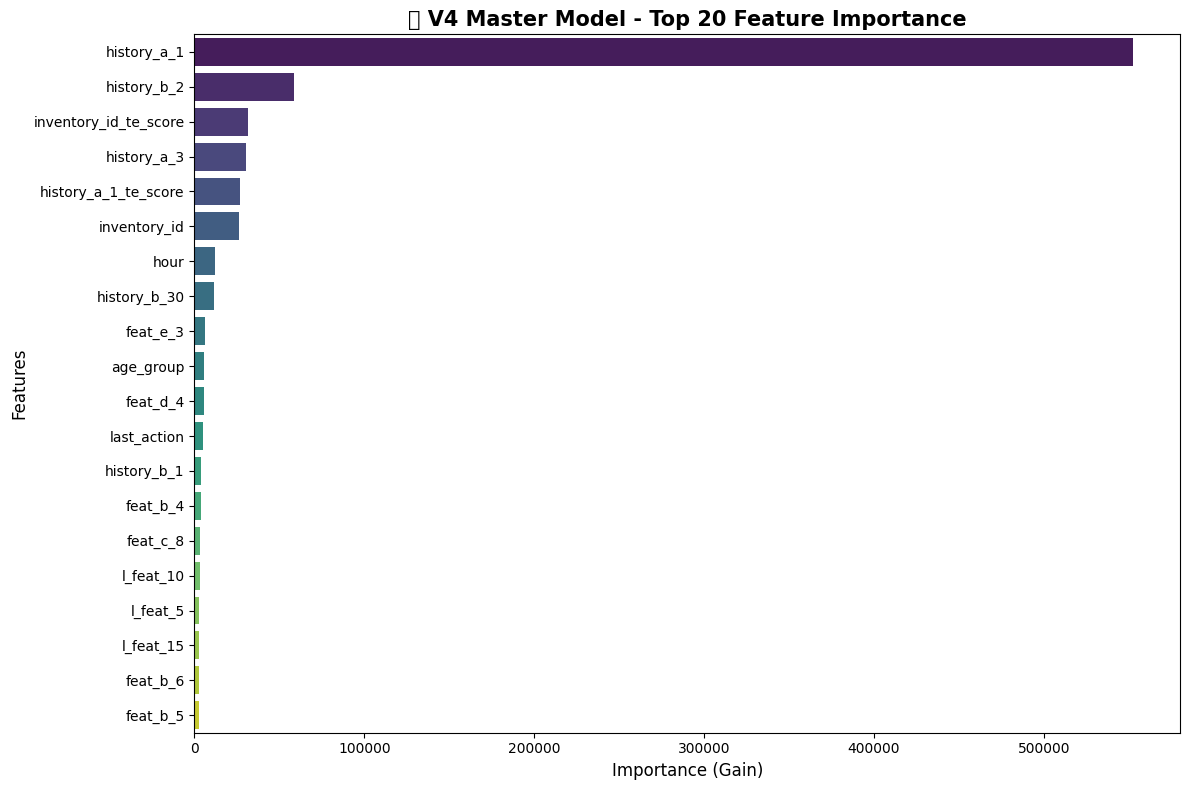


💾 V4 마스터 모델이 구글 드라이브에 영구 저장되었습니다!
📍 저장 위치: /content/drive/MyDrive/Colab Notebooks/CTR_Dacon/models/v4_lgbm_master_model.txt


In [ ]:
print("📊 [승리의 세리머니] 피처 중요도 확인 및 모델 저장 중...")

# 1. Feature Importance (Gain 기준) 데이터프레임 생성
fi_df = pd.DataFrame({
    'feature': model.feature_name(),
    'importance': model.feature_importance(importance_type='gain')
}).sort_values(by='importance', ascending=False)

# 2. 상위 20개 핵심 피처 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=fi_df.head(20), palette='viridis')
plt.title('🌟 V4 Master Model - Top 20 Feature Importance', fontsize=15, fontweight='bold')
plt.xlabel('Importance (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# 3. 소중한 V4 모델 구글 드라이브에 안전하게 저장
save_dir = '/content/drive/MyDrive/Colab Notebooks/CTR_Dacon/models'
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, 'v4_lgbm_master_model.txt')

model.save_model(model_path)
print("\n==================================================")
print(f"💾 V4 마스터 모델이 구글 드라이브에 영구 저장되었습니다!")
print(f"📍 저장 위치: {model_path}")
print("==================================================")

### 📊 V3 파이프라인 학습 결과 및 한계점 진단

- **성능 평가:** Valid AUC **0.7275** 기록. (이전 단계 대비 성능은 상승했으나, 목표 베이스라인인 0.7325에는 여전히 미치지 못함)
- **결과 진단:** Train AUC(0.792)와 Valid AUC(0.727) 간의 격차가 잔존하여, 모델이 여전히 훈련 데이터의 지엽적 패턴을 외우려는 과적합(Overfitting) 성향을 보이고 있음을 확인함.

#### 🔍 최종 베이스라인 돌파를 위한 V4 보완 전략 (Next Step)
완벽한 성능 개선 및 과적합 제어를 위해, 누락되었던 3가지 핵심 로직을 최종 파이프라인(V4)에 추가 반영하기로 결정함.

1. **유저 활동성 지표(`seq_len`) 부활:** 유저가 이전에 광고를 소비한 총 횟수를 파생 변수로 복구하여, 모델이 헤비 유저와 라이트 유저의 맥락적 차이를 인지하도록 유도함.
2. **원본 순정 카테고리(Category) 유지:** 타겟 인코딩 점수(`te_score`)만 남기고 삭제했던 원본 식별자(`inventory_id`, `history_a_1`)를 다시 살려, LightGBM 알고리즘 고유의 강력한 범주형 분할 기능을 100% 활용함.
3. **수학적 규제(L1/L2 Regularization) 강화:** `reg_alpha`(L1) 및 `reg_lambda`(L2) 파라미터를 강하게 부여하여, 특정 노이즈 변수에 가중치가 과도하게 쏠리는 현상을 물리적으로 억제함.



--- ---



# 실전 예측 및 제출 파일 생성

In [ ]:
import pandas as pd
import duckdb
import lightgbm as lgb
import time
import os
import gc

In [ ]:
start_time = time.time()
print("🚀 [Phase 4 진 진짜 최종본] 대문자 ID 방어 및 실전 예측 시작!")

# 1. 경로 설정
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/CTR_Dacon'
TRAIN_PATH = os.path.join(BASE_DIR, '원본데이터/train.parquet')
TEST_PATH = os.path.join(BASE_DIR, '원본데이터/test.parquet')
SAMPLE_SUB_PATH = os.path.join(BASE_DIR, '원본데이터/sample_submission.csv')

# 2. V4 마스터 모델 로드
print("📥 구글 드라이브에서 V4 마스터 모델 로드 중...")
model_path = os.path.join(BASE_DIR, 'models/v4_lgbm_master_model.txt')
model = lgb.Booster(model_file=model_path)

# 3. 테스트 데이터 DuckDB 전처리
print("⏳ 테스트 데이터 DuckDB 전처리 중...")
query_test = f"""
SELECT
    * EXCLUDE(seq),
    CASE
        WHEN seq IS NULL OR inventory_id IS NULL THEN 0.0
        WHEN list_position(list_reverse(string_split(seq, ',')), CAST(CAST(inventory_id AS BIGINT) AS VARCHAR)) IS NULL THEN 0.0
        ELSE (array_length(string_split(seq, ',')) - list_position(list_reverse(string_split(seq, ',')), CAST(CAST(inventory_id AS BIGINT) AS VARCHAR)) + 1) / CAST(array_length(string_split(seq, ',')) AS DOUBLE)
    END AS seq_match_score,
    string_split(seq, ',')[-1] AS last_action,
    array_length(string_split(seq, ',')) AS seq_len
FROM read_parquet('{TEST_PATH}')
"""
test_df = duckdb.query(query_test).to_df()
print(f"📊 테스트 데이터 로드 완료: {test_df.shape}")

# 4. 타겟 인코딩(TE) 맵핑 (메모리 초밀착 방어)
print("⏳ 타겟 인코딩(TE) 맵핑용 통계 추출 중...")
global_mean = duckdb.query(f"SELECT AVG(clicked) FROM read_parquet('{TRAIN_PATH}')").fetchone()[0]

inv_te_df = duckdb.query(f"SELECT inventory_id, AVG(clicked) as inventory_id_te_score FROM read_parquet('{TRAIN_PATH}') GROUP BY inventory_id").to_df()
test_df = test_df.merge(inv_te_df, on='inventory_id', how='left')
test_df['inventory_id_te_score'] = test_df['inventory_id_te_score'].fillna(global_mean)

hist_te_df = duckdb.query(f"SELECT history_a_1, AVG(clicked) as history_a_1_te_score FROM read_parquet('{TRAIN_PATH}') GROUP BY history_a_1").to_df()
test_df = test_df.merge(hist_te_df, on='history_a_1', how='left')
test_df['history_a_1_te_score'] = test_df['history_a_1_te_score'].fillna(global_mean)

del inv_te_df, hist_te_df
gc.collect()

# 5. 🌟 핵심 수정: 대문자 'ID'와 소문자 'id'를 모두 완벽하게 삭제!
print("🔪 변수 정리 및 모델 입력 준비 중...")
X_test = test_df.drop(columns=['id', 'ID', 'clicked'], errors='ignore')

# 1등 공신 변수들 카테고리 지정
cat_features = ['gender', 'age_group', 'day_of_week', 'hour', 'last_action', 'inventory_id', 'history_a_1']
for col in cat_features:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# 6. 예측 (Predict)
print("🔥 V4 마스터 모델로 최종 예측 수행 중...")
test_preds = model.predict(X_test)

# 7. 제출용 파일 생성
print("💾 submission.csv 파일 생성 중...")
sub_df = pd.read_csv(SAMPLE_SUB_PATH)
sub_df['clicked'] = test_preds

SUBMISSION_PATH = os.path.join(BASE_DIR, 'v4_master_submission.csv')
sub_df.to_csv(SUBMISSION_PATH, index=False)

end_time = time.time()
print("\n==================================================")
print(f"🎉 모든 과정 완료! 최종 제출 파일이 생성되었습니다.")
print(f"📍 파일 위치: {SUBMISSION_PATH}")
print(f"⏱️ 예측 및 저장 소요 시간: {end_time - start_time:.2f}초")
print("==================================================")

🚀 [Phase 4 진 진짜 최종본] 대문자 ID 방어 및 실전 예측 시작!
📥 구글 드라이브에서 V4 마스터 모델 로드 중...
⏳ 테스트 데이터 DuckDB 전처리 중...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📊 테스트 데이터 로드 완료: (1527298, 121)
⏳ 타겟 인코딩(TE) 맵핑용 통계 추출 중...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

🔪 변수 정리 및 모델 입력 준비 중...
🔥 V4 마스터 모델로 최종 예측 수행 중...
💾 submission.csv 파일 생성 중...

🎉 모든 과정 완료! 최종 제출 파일이 생성되었습니다.
📍 파일 위치: /content/drive/MyDrive/Colab Notebooks/CTR_Dacon/v4_master_submission.csv
⏱️ 예측 및 저장 소요 시간: 460.83초
